# Generador de resúmenes PLS (<3B)

Flujo end-to-end para preparar datos biomédicos, generar resúmenes en lenguaje sencillo, y dejar lista la receta de fine-tuning eficiente (QLoRA + PEFT) junto con evaluaciones básicas.

## Tabla de contenidos
- [1. Verificación de GPU y descarga de datos](#1-verificacion-de-gpu-y-descarga-de-datos)
- [2. Inventario del entorno y carpetas](#2-inventario-del-entorno-y-carpetas)
- [3. Preparación de modelo base y almacenamiento](#3-preparacion-de-modelo-base-y-almacenamiento)
- [4. Configuración global y utilidades](#4-configuracion-global-y-utilidades)
- [5. Generación de combinatorias y splits](#5-generacion-de-combinatorias-y-splits)
- [6. Chunking y tokenización](#6-chunking-y-tokenizacion)
- [7. Dependencias de métricas externas](#7-dependencias-de-metricas-externas)
- [8. Preparación de entrenamiento y evaluadores](#8-preparacion-de-entrenamiento-y-evaluadores)
- [9. Entrenamiento LoRA y guardado](#9-entrenamiento-lora-y-guardado)
- [10. Dependencias adicionales de evaluación](#10-dependencias-adicionales-de-evaluacion)
- [11. Persistencia y limpieza](#11-persistencia-y-limpieza)
- [12. Inferencia con pipeline HF](#12-inferencia-con-pipeline-hf)


## 1. Verificación de GPU y descarga de datos
Comprueba la GPU disponible y descomprime el repositorio con las fuentes de texto clínicas.

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sat Oct 25 01:24:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!unzip bridging-the-gap-in-health-literacy-main.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/773-MT_MED_9011_page8.txt  
  inflating: __MACOSX/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/._773-MT_MED_9011_page8.txt  
  inflating: bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/3142-MT_MED_9011_page8.txt  
  inflating: __MACOSX/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/._3142-MT_MED_9011_page8.txt  
  inflating: bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/10991-MT_MED_9011_page4.txt  
  inflating: __MACOSX/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sour

## 2. Inventario del entorno y carpetas
Revisa paquetes instalados y define un directorio de trabajo aislado para mantener artefactos ordenados.

In [ ]:
# What’s installed (top view)
!python -V
!pip --version
!pip list --format=columns | sed -n '1,120p'

# Detect conflicts quickly
#!pip check

# Dependency tree with conflicts highlighted
!pip -q install pipdeptree
!pipdeptree -w fail

# See reverse deps of a package (why it's pinned)
#!pipdeptree --reverse --packages numpy pandas scikit-learn transformers accelerate datasets evaluate


Se han truncado las últimas 5000 líneas del flujo de salida.
│   │   │   │   └── pyasn1 [required: >=0.6.1,<0.7.0, installed: 0.6.1]
│   │   │   └── rsa [required: >=3.1.4,<5, installed: 4.9.1]
│   │   │       └── pyasn1 [required: >=0.1.3, installed: 0.6.1]
│   │   ├── grpcio [required: >=1.33.2,<2.0.0, installed: 1.75.1]
│   │   │   └── typing_extensions [required: ~=4.12, installed: 4.15.0]
│   │   ├── proto-plus [required: >=1.22.3,<2.0.0, installed: 1.26.1]
│   │   │   └── protobuf [required: >=3.19.0,<7.0.0, installed: 5.29.5]
│   │   ├── protobuf [required: >=3.20.2,<7.0.0,!=4.21.5,!=4.21.4,!=4.21.3,!=4.21.2,!=4.21.1,!=4.21.0, installed: 5.29.5]
│   │   └── grpc-google-iam-v1 [required: >=0.14.0,<1.0.0, installed: 0.14.3]
│   │       ├── grpcio [required: >=1.44.0,<2.0.0, installed: 1.75.1]
│   │       │   └── typing_extensions [required: ~=4.12, installed: 4.15.0]
│   │       ├── googleapis-common-protos [required: >=1.56.0,<2.0.0, installed: 1.71.0]
│   │       │   └── protobu

In [1]:
# 1) Pick an isolated target dir
#PKG_DIR = "/kaggle/working/pkgs"

# 2) Install a compatible bundle there (pins avoid the conflicts you showed)
%pip -q install --upgrade-strategy eager --no-cache-dir \
  "numpy" "pandas" "scikit-learn==1.6.*" \
  "transformers==4.44.*" "datasets==2.20.*" "evaluate==0.4.*" \
  "peft==0.11.*" "rouge-score==0.1.2" "bert-score==0.3.13" "textstat==0.7.4" \
  "huggingface-hub==0.33.5"

# 3) Use those packages first on sys.path
#import sys, os
#os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"   # avoid torchvision import issues for pure NLP
#sys.path.insert(0, PKG_DIR)

# 4) (optional) prove it works
import transformers, datasets, evaluate, numpy, pandas, sklearn
print(transformers.__version__, datasets.__version__, evaluate.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 103.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 188.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 186.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 247.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 229.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 kB 215.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.7/515.7 kB 262.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 290.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 239.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 161.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the p

## 3. Preparación de modelo base y almacenamiento
Carga modelos ligeros decoder-only, comprime activos si es necesario y monta Google Drive para persistirlos.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME   = "Qwen/Qwen2.5-1.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

LOCAL_DIR = "./models/Qwen"
model.save_pretrained(LOCAL_DIR)
tokenizer.save_pretrained(LOCAL_DIR)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

('./models/Qwen/tokenizer_config.json',
 './models/Qwen/special_tokens_map.json',
 './models/Qwen/vocab.json',
 './models/Qwen/merges.txt',
 './models/Qwen/added_tokens.json')

In [ ]:
!zip -r -q qwen.zip ./models/Qwen

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Configuración global y utilidades
Importa librerías, fija configuración general y crea funciones para leer texto crudo y duplicar el DataFrame base.

In [1]:
import os, math, json, random, time
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [4]:
import torch
from datasets import load_dataset, DatasetDict
from typing import List, Dict, Optional, Tuple
import evaluate

# Métricas
rouge = evaluate.load("rouge")

try:
    from bert_score import score as bertscore_score
    HAVE_BERTSCORE = True
except Exception:
    HAVE_BERTSCORE = False

# Legibilidad
try:
    import textstat
    HAVE_TEXTSTAT = True
except Exception:
    HAVE_TEXTSTAT = False

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
# === CONFIG ===
BASE_DIR = Path('bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources')
OUTPUT_DIR = Path('drive/MyDrive/outputs_pls_classifier_v3'); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PARSE_PDFS = False
PDF_MIN_CHARS = 200

LABEL_BY_SOURCE_DEFAULT = {
    'Pfizer': 'pls',
    'Trial Summaries': 'pls',
    'ClinicalTrials.gov': 'non_pls'
}
LABEL_TO_INT = {'non_pls': 0, 'pls': 1}
INT_TO_LABEL = {0: 'non_pls', 1: 'pls'}

SOURCES = ['Cochrane','Pfizer','Trial Summaries','ClinicalTrials.gov']
RANDOM_STATE = 17
DEFAULT_TEST_SIZE = 0.2
VAL_SIZE = 0.15
DEDUPLICATE = True

print('BASE_DIR =', BASE_DIR.resolve())
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())


BASE_DIR = /content/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources
OUTPUT_DIR = /content/drive/MyDrive/outputs_pls_classifier_v3


In [ ]:

def read_txt_file(path: Path) -> Optional[str]:
    try:
        t = path.read_text(encoding='utf-8', errors='ignore').strip()
        return t if t else None
    except Exception:
        return None

def read_pdf_file(path: Path) -> Optional[str]:
    if not PARSE_PDFS:
        return None
    try:
        from PyPDF2 import PdfReader
    except Exception:
        return None
    try:
        reader = PdfReader(str(path))
        parts = []
        for page in reader.pages:
            txt = page.extract_text() or ''
            if txt and len(txt) >= PDF_MIN_CHARS:
                parts.append(txt)
        text = '\n'.join(parts).strip()
        return text if text else None
    except Exception:
        return None

def iter_texts_in_dir(root: Path, exts=('.txt',)) -> List[Path]:
    return [p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in exts]

def normalize_for_dedup(s: str) -> str:
    return ' '.join((s or '').lower().split())

def load_cochrane(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Cochrane'
    if not root.exists(): return out
    for subset in ['train','test']:
        for cls in ['pls','non_pls']:
            cdir = root / subset / cls
            if not cdir.exists(): continue
            for p in iter_texts_in_dir(cdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':cls,'source':'Cochrane','subset':subset,'path':str(p)})
    return out

def load_pfizer(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Pfizer'
    if not root.exists(): return out
    for subset in ['train','test']:
        sdir = root / subset
        if sdir.exists():
            for p in iter_texts_in_dir(sdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Pfizer','pls'),
                                'source':'Pfizer','subset':subset,'path':str(p)})
    for p in (root / 'original_pfizer_texts').rglob('*.pdf') if (root / 'original_pfizer_texts').exists() else []:
        t = read_pdf_file(p)
        if t:
            out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Pfizer','pls'),
                        'source':'Pfizer','subset':'unspecified','path':str(p)})
    return out

def load_trial_summaries(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Trial Summaries'
    if not root.exists(): return out
    for tf in ['med','alx']:
        tfdir = root / tf
        if tfdir.exists():
            for p in iter_texts_in_dir(tfdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Trial Summaries','pls'),
                                'source':'Trial Summaries','subset':'unspecified','path':str(p)})
    orig = root / 'original_texts'
    if orig.exists():
        for p in orig.rglob('*.pdf'):
            t = read_pdf_file(p)
            if t:
                out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Trial Summaries','pls'),
                            'source':'Trial Summaries','subset':'unspecified','path':str(p)})
    return out

def load_clinicaltrials_gov(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'ClinicalTrials.gov'
    if not root.exists(): return out
    for subset in ['train','test']:
        sdir = root / subset
        if sdir.exists():
            for p in iter_texts_in_dir(sdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('ClinicalTrials.gov','non_pls'),
                                'source':'ClinicalTrials.gov','subset':subset,'path':str(p)})
    return out

def load_all(base_dir: Path, sources: List[str]) -> pd.DataFrame:
    recs = []
    if 'Cochrane' in sources: recs += load_cochrane(base_dir)
    if 'Pfizer' in sources: recs += load_pfizer(base_dir)
    if 'Trial Summaries' in sources: recs += load_trial_summaries(base_dir)
    if 'ClinicalTrials.gov' in sources: recs += load_clinicaltrials_gov(base_dir)
    df = pd.DataFrame(recs)
    if df.empty:
        print('⚠️ No se encontraron textos. Revisa rutas.')
        return df
    df['label_int'] = df['label'].map({'non_pls':0,'pls':1})
    df['subset'] = df['subset'].fillna('unspecified')
    df['n_chars'] = df['text'].str.len()
    return df

df_raw = load_all(BASE_DIR, SOURCES)
print('Total textos:', len(df_raw))
df_raw.head(3)

Total textos: 61363


,text,label,source,subset,path,label_int,n_chars
0,Sealants for preventing tooth decay in permane...,pls,Cochrane,train,bridging-the-gap-in-health-literacy-main/data_...,1,2097
1,High‐dose chemotherapy with autologous stem ce...,pls,Cochrane,train,bridging-the-gap-in-health-literacy-main/data_...,1,4404
2,Antidepressants for treating depression in dem...,pls,Cochrane,train,bridging-the-gap-in-health-literacy-main/data_...,1,3210


Deduplicación: 61363 -> 61325 (elim 38)

Etiquetas:
label
non_pls    39525
pls        21800
Name: count, dtype: int64

Fuentes:
source
Cochrane              58940
Trial Summaries        1034
ClinicalTrials.gov      751
Pfizer                  600
Name: count, dtype: int64


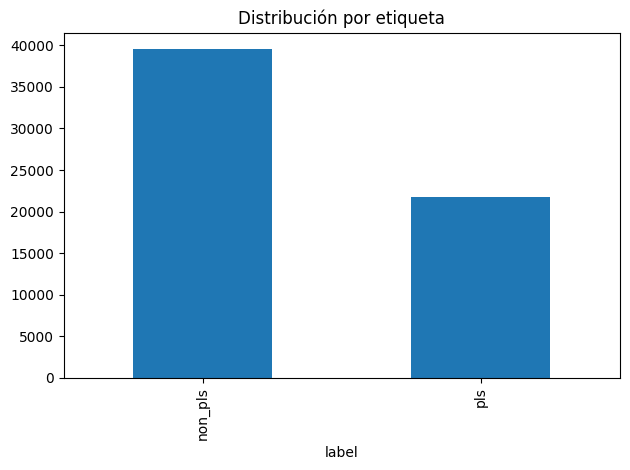

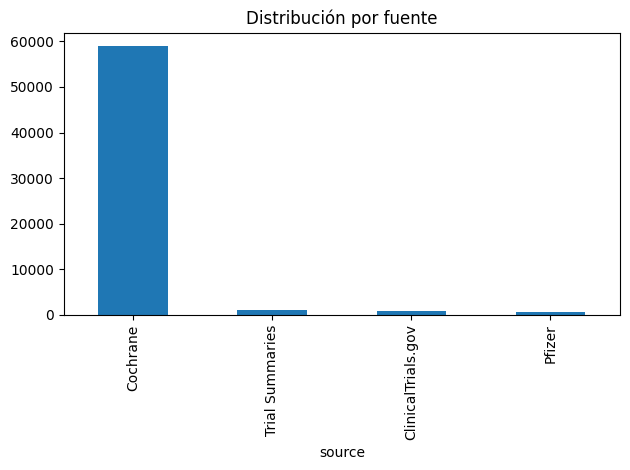

In [ ]:
df = df_raw.copy()
if not df.empty and DEDUPLICATE:
    before = len(df)
    key = df['text'].map(normalize_for_dedup)
    df = df.loc[~key.duplicated()].reset_index(drop=True)
    after = len(df)
    print(f'Deduplicación: {before} -> {after} (elim {before-after})')
else:
    print('Deduplicación desactivada o DF vacío.')

print('\nEtiquetas:'); print(df['label'].value_counts())
print('\nFuentes:'); print(df['source'].value_counts())

plt.figure()
df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución por etiqueta')
plt.tight_layout(); plt.show()

plt.figure()
df['source'].value_counts().plot(kind='bar')
plt.title('Distribución por fuente')
plt.tight_layout(); plt.show()

In [ ]:
from pathlib import Path
import re
import pandas as pd


# Regex to capture base_id and type:
# Examples:
#  10.1002-14651858.CD000006.pub2-abstract.txt
#  10.1002-14651858.CD000006.pub2-abstract.txt_accumulated_section13
#  10.1002-14651858.CD000006.pub2-pls.txt
PAT = re.compile(
    r"""
    ^(?P<base_id>.+?)                 # everything up to the final -abstract/-pls
    -
    (?P<kind>pls|abstract)            # 'pls' or 'abstract'
    \.txt                             # .txt
    (?P<suffix>.*)?$                  # optional tail (e.g., _accumulated_section13)
    """,
    re.VERBOSE | re.IGNORECASE
)

VALID_EXTS = {".txt"}  # adjust if needed

def parse_file(p: Path):
    """Return (base_id, label, path) or None if not matching."""
    if not p.is_file() or p.suffix.lower() not in VALID_EXTS:
        return None
    m = PAT.match(p.name)
    if not m:
        return None
    base_id = m.group("base_id")
    kind = m.group("kind").lower()
    # Label rules:
    #  - '-pls.txt' => pls
    #  - '-abstract.txt' (+ any extra tail) => non_pls
    label = "pls" if kind == "pls" else "non_pls"
    return base_id, label, str(p)

# Scan
rows = []
for p in BASE_DIR.rglob("*"):
    parsed = parse_file(p)
    if parsed:
        base_id, label, path = parsed
        rows.append({"base_id": base_id, "label": label, "path": path})

df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit("No matching files found. Check BASE path or patterns.")

# Pivot to gather all non_pls variants vs the single/multiple pls per base_id
def agg_paths(series):
    return " | ".join(sorted(series))

pivot = df.pivot_table(index=["base_id"],
                       columns="label",
                       values="path",
                       aggfunc=agg_paths,
                       fill_value="")
pivot = pivot.reset_index()

# Ensure both columns exist
for col in ["pls", "non_pls"]:
    if col not in pivot.columns:
        pivot[col] = ""

pivot["has_pls"] = pivot["pls"].str.len() > 0
pivot["has_non_pls"] = pivot["non_pls"].str.len() > 0
pivot["pair_type"] = pivot.apply(
    lambda r: "both" if (r["has_pls"] and r["has_non_pls"])
    else ("only_pls" if r["has_pls"] else ("only_non_pls" if r["has_non_pls"] else "none")),
    axis=1
)

equivalences_df = pivot.rename(columns={
    "pls": "pls_paths",
    "non_pls": "non_pls_paths"
})[["base_id","pls_paths","non_pls_paths","has_pls","has_non_pls","pair_type"]]

# Summaries
print("=== Overall Summary ===")
print("total base_ids:", len(equivalences_df))
print("with both     :", int((equivalences_df.pair_type == "both").sum()))
print("only pls      :", int((equivalences_df.pair_type == "only_pls").sum()))
print("only non_pls  :", int((equivalences_df.pair_type == "only_non_pls").sum()))

print("\nSample rows:")
print(equivalences_df.head(10))

# Save CSV
equivalences_df.to_csv("equivalences_pls_nonpls_by_base_id.csv", index=False)
print("\nSaved to equivalences_pls_nonpls_by_base_id.csv")


=== Overall Summary ===
total base_ids: 8327
with both     : 5595
only pls      : 25
only non_pls  : 2707

Sample rows:
label                         base_id  \
0      10.1002-14651858.CD000004.pub2   
1      10.1002-14651858.CD000006.pub2   
2      10.1002-14651858.CD000008.pub2   
3      10.1002-14651858.CD000009.pub4   
4      10.1002-14651858.CD000011.pub4   
5      10.1002-14651858.CD000012.pub4   
6      10.1002-14651858.CD000013.pub2   
7      10.1002-14651858.CD000014.pub4   
8           10.1002-14651858.CD000016   
9      10.1002-14651858.CD000019.pub3   

label                                          pls_paths  \
0      bridging-the-gap-in-health-literacy-main/data_...   
1      bridging-the-gap-in-health-literacy-main/data_...   
2                                                          
3      bridging-the-gap-in-health-literacy-main/data_...   
4      bridging-the-gap-in-health-literacy-main/data_...   
5      bridging-the-gap-in-health-literacy-main/data_...   
6       

## 5. Generación de combinatorias y splits
Construye pares PLS/non-PLS a partir de cada documento y divide en train/test para futuros ajustes finos.

In [ ]:
# --- PLS <-> non-PLS: crear todas las combinatorias por documento ---
from pathlib import Path
import re
import pandas as pd

# 1) Configura la carpeta donde están los .txt
OUT_CSV  = OUTPUT_DIR / "pls_nonpls_combinatory_texts.csv"

# 2) Patrón: extrae base_id y tipo (pls|abstract). Ignora cualquier sufijo después de .txt
PAT = re.compile(r"^(?P<base_id>.+?)-(?P<kind>pls|abstract)\.txt(?P<suffix>.*)?$", re.IGNORECASE)

def read_text_safe(path: Path) -> str:
    try:
        return path.read_text(encoding="utf-8", errors="ignore").strip()
    except Exception:
        return ""

# 3) Indexar archivos y etiquetar (non_pls vs pls)
rows = []
for p in BASE_DIR.rglob("*.txt"):
    m = PAT.match(p.name)
    if not m:
        continue
    base_id = m.group("base_id")
    kind = m.group("kind").lower()  # 'pls' o 'abstract'
    label = "pls" if kind == "pls" else "non_pls"
    rows.append({"base_id": base_id, "label": label, "path": str(p)})

files_df = pd.DataFrame(rows).sort_values(["base_id","label","path"]).reset_index(drop=True)

if files_df.empty:
    raise SystemExit(f"No se encontraron .txt válidos en {BASE_DIR}. Revisa ruta y nombres.")

# 4) Producto cartesiano por base_id: todas las combinatorias non_pls × pls
pairs = []
for bid, grp in files_df.groupby("base_id"):
    nonp = grp[grp["label"] == "non_pls"]["path"].tolist()
    pls  = grp[grp["label"] == "pls"]["path"].tolist()
    if not nonp or not pls:
        continue
    for a in nonp:
        for b in pls:
            pairs.append({"base_id": bid, "non_pls_path": a, "pls_path": b})

combo_df = pd.DataFrame(pairs)

if combo_df.empty:
    raise SystemExit("No hubo documentos con ambas clases (non_pls y pls) para combinar.")

# 5) Adjuntar textos y quitar duplicados exactos de paths
combo_df["non_pls_text"] = combo_df["non_pls_path"].map(lambda s: read_text_safe(Path(s)))
combo_df["pls_text"]     = combo_df["pls_path"].map(lambda s: read_text_safe(Path(s)))

before = len(combo_df)
combo_df = combo_df.drop_duplicates(subset=["non_pls_path","pls_path"]).reset_index(drop=True)
after = len(combo_df)

# 6) (Opcional) Guarda CSV con solo las 4 columnas solicitadas
final_cols = ["non_pls_path","pls_path","non_pls_text","pls_text"]
if OUT_CSV:
    combo_df[final_cols].to_csv(OUT_CSV, index=False)

# 7) Resumen y vista previa
summary = {
    "unique_base_ids_with_pairs": int(combo_df["base_id"].nunique()),
    "total_pairs_created": int(after),
    "duplicates_removed": int(before - after),
}
print("Resumen:", summary)
print("\nVista previa:")
display(combo_df[final_cols].head(10))  # si no usas Jupyter, sustituye por print(combo_df[final_cols].head(10))


Resumen: {'unique_base_ids_with_pairs': 5595, 'total_pairs_created': 129985, 'duplicates_removed': 0}

Vista previa:


,non_pls_path,pls_path,non_pls_text,pls_text
0,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background\nApproximately 70% of women will ex...,Absorbable stitches for repair of episiotomy a...
1,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background\nApproximately 70% of women will ex...,Absorbable stitches for repair of episiotomy a...
2,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...
3,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...
4,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...
5,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...
6,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...
7,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...
8,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...
9,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...


In [ ]:
# --- Split train/test para fine-tuning PLS (Qwen u otros) ---

from pathlib import Path
import re
import pandas as pd
import numpy as np

# Asume que ya definiste: BASE_DIR, OUT_CSV, combo_df, final_cols como en tu snippet previo
# Si no, asegúrate de tener combo_df con columnas: non_pls_path, pls_path, non_pls_text, pls_text, base_id

def infer_subset_from_path(path_str: str) -> str:
    """Devuelve 'train' o 'test' si está en la ruta; de lo contrario 'unspecified'."""
    parts = path_str.lower().split("/")
    if "train" in parts: return "train"
    if "test"  in parts: return "test"
    return "unspecified"

# 1) Inferir subset por cada lado y definir pair_subset
combo_df["non_pls_subset"] = combo_df["non_pls_path"].map(infer_subset_from_path)
combo_df["pls_subset"]     = combo_df["pls_path"].map(infer_subset_from_path)
combo_df["pair_subset"]    = np.where(
    combo_df["non_pls_subset"] == combo_df["pls_subset"],
    combo_df["non_pls_subset"],
    "mixed"
)

# 2) Filtrar pares "puros" (train/train o test/test)
pure_df = combo_df[combo_df["pair_subset"].isin(["train","test"])].copy()

# 3) Estrategia principal: usar pares puros
if not pure_df.empty and pure_df["pair_subset"].nunique() >= 1:
    df_train = pure_df[pure_df["pair_subset"]=="train"][["non_pls_path","pls_path","non_pls_text","pls_text","base_id"]].reset_index(drop=True)
    df_test  = pure_df[pure_df["pair_subset"]=="test" ][["non_pls_path","pls_path","non_pls_text","pls_text","base_id"]].reset_index(drop=True)

    # Si no hay test puro, hacemos fallback estratificado para crear test desde train puro
    if df_test.empty and len(df_train) > 1:
        # Split por base_id para evitar fuga de documento
        rng = np.random.RandomState(42)
        ids = df_train["base_id"].drop_duplicates().sample(frac=1.0, random_state=42).tolist()
        n_test_ids = max(1, int(round(0.1 * len(ids))))  # 10% para test
        test_ids = set(ids[:n_test_ids])
        mask_test = df_train["base_id"].isin(test_ids)
        df_test = df_train[mask_test].reset_index(drop=True)
        df_train = df_train[~mask_test].reset_index(drop=True)

else:
    # 4) Fallback total: no hay pares puros. Hacemos split estratificado por base_id con TODO el combo_df.
    #    (mantén el esquema de 4 columnas + base_id)
    tmp = combo_df[["non_pls_path","pls_path","non_pls_text","pls_text","base_id"]].copy()
    ids = tmp["base_id"].drop_duplicates().sample(frac=1.0, random_state=42).tolist()
    n_test_ids = max(1, int(round(0.1 * len(ids))))  # 10% para test
    test_ids = set(ids[:n_test_ids])
    mask_test = tmp["base_id"].isin(test_ids)
    df_test  = tmp[mask_test].reset_index(drop=True)
    df_train = tmp[~mask_test].reset_index(drop=True)

# 5) (Opcional) Guardar a disco
OUTPUT_DIR = Path(OUT_CSV).parent if OUT_CSV else Path(".")
OUT_TRAIN = OUTPUT_DIR / "pls_train_pairs.csv"
OUT_TEST  = OUTPUT_DIR / "pls_test_pairs.csv"
df_train.to_csv(OUT_TRAIN, index=False)
df_test.to_csv(OUT_TEST,  index=False)

# 6) Resumen útil para entrenamiento
summary_split = {
    "pairs_total": int(len(combo_df)),
    "pairs_puros_total": int(len(pure_df)),
    "pairs_train": int(len(df_train)),
    "pairs_test": int(len(df_test)),
    "base_ids_train": int(df_train["base_id"].nunique()) if not df_train.empty else 0,
    "base_ids_test": int(df_test["base_id"].nunique()) if not df_test.empty else 0,
    "had_pure_subsets": bool(not pure_df.empty),
}
print("Resumen split:", summary_split)
print("Train ->", OUT_TRAIN)
print("Test  ->", OUT_TEST)

# 7) DataFrames finales (para Qwen u otro LLM):
#    - Entrada: column 'non_pls_text'  (source)
#    - Salida : column 'pls_text'      (target)
# Ejemplo mínimo: convertir a HF datasets (opcional)
try:
    from datasets import Dataset
    ds_train = Dataset.from_pandas(df_train[["non_pls_text","pls_text"]].rename(
        columns={"non_pls_text":"source_text","pls_text":"target_text"}
    ))
    ds_test  = Dataset.from_pandas(df_test[["non_pls_text","pls_text"]].rename(
        columns={"non_pls_text":"source_text","pls_text":"target_text"}
    ))
    print(ds_train, ds_test)
except Exception as e:
    print("Error: ", e)


NameError: name 'combo_df' is not defined

In [6]:
# Define the path to the CSV file
#OUT_CSV_TRAIN = OUTPUT_DIR / "pls_train_pairs.csv"
#OUT_CSV_TEST = OUTPUT_DIR / "pls_test_pairs.csv"

OUT_CSV_TRAIN = "data" / "pls_train_pairs.csv"
OUT_CSV_TEST = "data" / "pls_test_pairs.csv"

# Load the data into a pandas DataFrame
df_train = pd.read_csv(OUT_CSV_TRAIN)
df_test = pd.read_csv(OUT_CSV_TEST)

# Display the first few rows of the DataFrame
print(f"Numero de registros train: {len(df_train)}")
print(f"Numero de registros test: {len(df_test)}")
print("Vista previa del DataFrame df_train:")
display(df_train.head())

Numero de registros train: 84908
Numero de registros test: 4535
Vista previa del DataFrame combo_df:


,non_pls_path,pls_path,non_pls_text,pls_text,base_id
0,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background\nApproximately 70% of women will ex...,Absorbable stitches for repair of episiotomy a...,10.1002-14651858.CD000006.pub2
1,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background\nApproximately 70% of women will ex...,Absorbable stitches for repair of episiotomy a...,10.1002-14651858.CD000006.pub2
2,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...,10.1002-14651858.CD000009.pub4
3,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...,10.1002-14651858.CD000009.pub4
4,bridging-the-gap-in-health-literacy-main/data_...,bridging-the-gap-in-health-literacy-main/data_...,Background \nAcupuncture and related technique...,Do acupuncture and related therapies help smok...,10.1002-14651858.CD000009.pub4


## 6. Chunking y tokenización
Define utilidades para fragmentar texto por tokens y gestionar solapamiento antes de alimentar al modelo.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig

def load_generator(model_id: str, max_new_tokens=256, use_4bit=True, attn_impl="flash_attention_2"):
    model_kwargs = {"device_map": "auto"}
    #if use_4bit and torch.cuda.is_available():
    #    bnb_config = BitsAndBytesConfig(
    #        load_in_4bit=True,
    #        bnb_4bit_quant_type="nf4",
    #        bnb_4bit_use_double_quant=True,
    #        bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
    #    )
    #    model_kwargs["quantization_config"] = bnb_config
    #else:
        # CPU o sin 4bit
    #    model_kwargs["torch_dtype"] = torch.float32 if not torch.cuda.is_available() else torch.bfloat16

    # En Qwen2.5 conviene permitir remote code (clases nuevas del modelo)
    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
   #     trust_remote_code=True,
        torch_dtype="auto",
        device_map="auto",
   #     attn_implementation=attn_impl if torch.cuda.is_available() else None,
   #     **model_kwargs,
    )
    gen = pipeline("text-generation", model=model, tokenizer=tok)
    if gen.tokenizer.pad_token is None and gen.tokenizer.eos_token is not None:
        gen.tokenizer.pad_token = gen.tokenizer.eos_token
    gen.model.generation_config.pad_token_id = gen.tokenizer.pad_token_id
    return gen, tok


MODEL_IDS = [
    "Qwen/Qwen2.5-1.5B-Instruct",
    #"meta-llama/Llama-3.2-1B-Instruct",
    # "google/gemma-2-2b-it",   # requiere aceptar licencia
    # "microsoft/phi-2",
]

PRIMARY_MODEL = MODEL_IDS[0]
gen, tok = load_generator(PRIMARY_MODEL, use_4bit=True)
print(type(gen.model), tok.model_max_length)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

<class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'> 131072


In [ ]:

def chunk_by_tokens(text:str, tokenizer, max_input_tokens=1024, overlap=50):
    ids = tokenizer(text, add_special_tokens=False)["input_ids"]
    chunks = []
    i = 0
    while i < len(ids):
        j = min(i + max_input_tokens, len(ids))
        sub = ids[i:j]
        chunks.append(tokenizer.decode(sub, skip_special_tokens=True))
        if j == len(ids):
            break
        i = j - overlap
        i = max(i, 0)
    return chunks


def df_to_records_text_only(df):
    recs = []
    for _, r in df.iterrows():
        recs.append({
            "article": r["text"],
            "summary": ""
        })
    return recs


def prompt_pls_chunk(chunk):
    return f"""You are a science communicator. Write a clear plain-language micro-summary for a lay audience.
            Rules:
            - Use simple words, short sentences (<=18 words), and no jargon.
            - Briefly define any necessary technical term.
            - Focus on key findings and why they matter.
            - 4-6 sentences, neutral tone.

            Text: {chunk}

            Plain-language micro-summary:
            """

def prompt_reduce_pls(micro_summaries):
    joined = "\n- ".join(micro_summaries)
    return f"""You are a science communicator. Merge the bullet micro-summaries into a single plain-language summary for a non-expert.
            Constraints:
            - 8-12 sentences, clear and concise.
            - No jargon; define any necessary term in simple words.
            - Cover: what was studied, how, main findings, and limitations.
            - Avoid speculation and keep statements grounded in the provided bullets.

            Bullets:
            - {joined}

            Unified plain-language summary:
            """


## 7. Dependencias de métricas externas
Instala AlignScore u otras métricas externas necesarias para evaluación posterior.

In [7]:
!pip install git+https://github.com/yuh-zha/AlignScore.git

  Cloning https://github.com/yuh-zha/AlignScore.git to /tmp/pip-req-build-khqu_j02
  Running command git clone --filter=blob:none --quiet https://github.com/yuh-zha/AlignScore.git /tmp/pip-req-build-khqu_j02
  Resolved https://github.com/yuh-zha/AlignScore.git to commit a0936d5afee642a46b22f6c02a163478447aa493
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of alignscore to determine which version is compatible with other requirements. This could take a while.
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement torch

## 8. Preparación de entrenamiento y evaluadores
Agrupa importaciones, funciones de legibilidad y collators para lanzar el entrenamiento.

In [ ]:
# ===========================================
# Evaluación PLS: Factualidad, Legibilidad, Relevancia
# Requiere: textstat, evaluate (o bert-score), AlignScore (opcional pero recomendado)
# ===========================================
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import math

# ---------- Imports con tolerancia ----------
# Readability
try:
    import textstat
    HAVE_TEXTSTAT = True
except Exception:
    HAVE_TEXTSTAT = False

# BERTScore (vía evaluate o bert_score)
try:
    import evaluate
    bertscore_metric = evaluate.load("bertscore")
    def compute_bertscore(preds, refs, lang="en"):
        res = bertscore_metric.compute(predictions=preds, references=refs, lang=lang)
        return {
            "bert_precision": float(np.mean(res["precision"])),
            "bert_recall": float(np.mean(res["recall"])),
            "bert_f1": float(np.mean(res["f1"]))
        }
except Exception:
    try:
        from bert_score import score as bertscore_score
        def compute_bertscore(preds, refs, lang="en"):
            P, R, F1 = bertscore_score(preds, refs, lang=lang, verbose=False)
            return {
                "bert_precision": float(P.mean()),
                "bert_recall": float(R.mean()),
                "bert_f1": float(F1.mean())
            }
    except Exception:
        def compute_bertscore(*args, **kwargs):
            return {}

# AlignScore (factualidad)
# API esperada del repo oficial: AlignScorer(model="...", batch_size=..., device=...)
try:
    from alignscore import AlignScorer
    HAVE_ALIGNSCORE = True
except Exception:
    HAVE_ALIGNSCORE = False

# Fallback a NLI si no hay AlignScore
_aligner = None
def _init_align_model(device=None):
    global _aligner
    if HAVE_ALIGNSCORE:
        # Modelos disponibles en el repo; 'roberta-large' suele ser buena base; ajusta si prefieres otro checkpoint
        _aligner = AlignScorer(model="roberta-large", batch_size=8, device=device)
    else:
        # Fallback NLI (DeBERTa MNLI) para un proxy de factualidad por contradicción/entailment
        try:
            from transformers import AutoTokenizer, AutoModelForSequenceClassification
            import torch
            nli_ckpt = "microsoft/deberta-large-mnli"
            _aligner = {
                "tok": AutoTokenizer.from_pretrained(nli_ckpt),
                "mdl": AutoModelForSequenceClassification.from_pretrained(nli_ckpt).to(device or ("cuda" if torch.cuda.is_available() else "cpu")),
                "dev": device or ("cuda" if torch.cuda.is_available() else "cpu"),
                "torch": __import__("torch")
            }
        except Exception:
            _aligner = None

def compute_alignscore(sources, hypos, device=None):
    """
    Devuelve un dict con 'alignscore_mean' y la lista 'alignscore_all'.
    Si no hay AlignScore y no se pudo cargar NLI fallback, devuelve {}.
    """
    if not sources or not hypos:
        return {}
    if len(sources) != len(hypos):
        # Asegura tamaños iguales
        n = min(len(sources), len(hypos))
        sources = sources[:n]; hypos = hypos[:n]

    if HAVE_ALIGNSCORE:
        if _aligner is None:
            _init_align_model(device=device)
        try:
            scores = _aligner.score(sources, hypos)  # lista de floats
            return {
                "alignscore_mean": float(np.mean(scores)),
                "alignscore_all": [float(x) for x in scores],
                "alignscore_backend": "AlignScore"
            }
        except Exception:
            pass

    # ---- Fallback NLI: proxy factualidad (entailment prob) ----
    if isinstance(_aligner, dict):
        torch = _aligner["torch"]
        tok = _aligner["tok"]
        mdl = _aligner["mdl"]
        dev = _aligner["dev"]
        mdl.eval()
        batch_scores = []
        bs = 8
        with torch.no_grad():
            for i in range(0, len(sources), bs):
                prem = sources[i:i+bs]    # source
                hypo = hypos[i:i+bs]      # prediction
                toks = tok(prem, hypo, padding=True, truncation=True, return_tensors="pt", max_length=512).to(dev)
                logits = mdl(**toks).logits
                probs = torch.softmax(logits, dim=-1)  # [contradiction, neutral, entailment]
                entail = probs[:, 2].detach().cpu().numpy().tolist()
                batch_scores.extend(entail)
        return {
            "alignscore_mean": float(np.mean(batch_scores)),
            "alignscore_all": [float(x) for x in batch_scores],
            "alignscore_backend": "NLI-fallback (entailment prob)"
        }

    return {}

# ---------- Prompts/Chunking (tus funciones existentes) ----------
# Debes tener definidas:
#   - chunk_by_tokens(text, tok, max_input_tokens)
#   - prompt_pls_chunk(chunk_text)
#   - prompt_reduce_pls(micro_summaries_list)
#   - 'gen' (pipeline/generator) y 'tok' (tokenizer del generador)

def _get_source_text(row):
    return (row.get("non_pls_text") or row.get("text") or "")

def _get_target_text(row):
    return (row.get("pls_text") or row.get("summary") or "")

def generate_pls_for_row(row, gen, tok, max_input_tokens=1024, max_new_tokens=300, temperature=0.3):
    article = _get_source_text(row)
    if not article:
        return ""
    chunks = chunk_by_tokens(article, tok, max_input_tokens=max_input_tokens)
    micro_sums = []
    for ch in chunks:
        out = gen(
            prompt_pls_chunk(ch),
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature
        )[0]["generated_text"]
        micro = out.split("Plain-language micro-summary:")[-1].strip()
        micro_sums.append(micro)

    out_final = gen(
        prompt_reduce_pls(micro_sums),
        max_new_tokens=400,
        do_sample=False,
        temperature=0.0
    )[0]["generated_text"]

    pred = out_final.split("Unified plain-language summary:")[-1].strip()
    return pred

def compute_readability(texts):
    """Calcula métricas de legibilidad sobre una lista de cadenas."""
    res = {}
    if not HAVE_TEXTSTAT or not texts:
        return res
    # textstat maneja strings individualmente; aquí calculamos promedio
    def _safe(func, x, default=np.nan):
        try:
            return func(x)
        except Exception:
            return default

    fkgl  = [ _safe(textstat.flesch_kincaid_grade, t)          for t in texts ]
    cli   = [ _safe(textstat.coleman_liau_index, t)             for t in texts ]
    fre   = [ _safe(textstat.flesch_reading_ease, t)            for t in texts ]
    fog   = [ _safe(textstat.gunning_fog, t)                    for t in texts ]
    smog  = [ _safe(textstat.smog_index, t)                     for t in texts ]
    dale  = [ _safe(textstat.dale_chall_readability_score, t)   for t in texts ]

    # Limpia NaNs antes de promediar
    def mean_valid(arr):
        arr = [x for x in arr if x is not None and not (isinstance(x, float) and math.isnan(x))]
        return float(np.mean(arr)) if arr else float("nan")

    res["flesch_kincaid_grade"]     = mean_valid(fkgl)
    res["coleman_liau_index"]       = mean_valid(cli)
    res["flesch_reading_ease"]      = mean_valid(fre)
    res["gunning_fog_index"]        = mean_valid(fog)
    res["smog_index"]               = mean_valid(smog)
    res["dale_chall_readability"]   = mean_valid(dale)
    return res

def evaluate_df(df, gen, tok, max_input_tokens=1024, show_examples=False, bert_lang="en", device=None):
    """
    df: DataFrame con columnas non_pls_text (source) y pls_text (ref).
    Devuelve:
      - metrics: {'factuality': {...}, 'readability': {...}, 'relevance': {...}}
      - preds: lista de resúmenes generados
      - refs:  lista de referencias (pueden venir vacías)
      - srcs:  lista de fuentes
    """
    preds, refs, srcs = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        pred = generate_pls_for_row(row, gen, tok, max_input_tokens=max_input_tokens)
        src  = _get_source_text(row)
        ref  = _get_target_text(row)

        if show_examples:
            print(f"→ PRED: {pred[:140]}...")

        preds.append("" if pred is None else str(pred))
        refs.append(""  if ref  is None else str(ref))
        srcs.append(""  if src  is None else str(src))

    # ---- Relevancia (BERTScore) ----
    pairs_for_ref = [(p, r) for p, r in zip(preds, refs) if (r or "").strip()]
    relevance = {}
    if pairs_for_ref:
        p2, r2 = zip(*pairs_for_ref)
        relevance = compute_bertscore(list(p2), list(r2), lang=bert_lang)

    # ---- Factualidad (AlignScore o fallback NLI) ----
    # Compara fuente (src) vs predicción (pred)
    pairs_for_src = [(s, p) for s, p in zip(srcs, preds) if (s or "").strip() and (p or "").strip()]
    factuality = {}
    if pairs_for_src:
        s2, p2 = zip(*pairs_for_src)
        factuality = compute_alignscore(list(s2), list(p2), device=device)

    # ---- Legibilidad (sobre preds) ----
    readability = compute_readability(preds)

    return {"factuality": factuality, "readability": readability, "relevance": relevance}, preds, refs, srcs

# ================== EJEMPLO DE USO ==================
# Asume que ya tienes df_train y df_test con columnas:
#   - non_pls_text (source)  - obligatorio para generar
#   - pls_text     (target)  - para relevancia (BERTScore)
safe_max_len = getattr(tok, "model_max_length", 2048) or 2048
max_input_tokens = min(safe_max_len//2, 1024)

# Inicializar AlignScore o fallback NLI (una vez)
_init_align_model(device=None)  # device="cuda" si quieres forzarlo

# BASELINE
metrics_test, preds_test, refs_test, srcs_test = evaluate_df(
  df_test[:5], gen, tok, max_input_tokens=max_input_tokens, show_examples=False, bert_lang="en", device=None
)
print("\n=== TEST ===")
print("Factualidad:", {k:v for k,v in metrics_test["factuality"].items() if k!="alignscore_all"})
print("Legibilidad:", metrics_test["readability"])
print("Relevancia (BERTScore):", metrics_test["relevance"])


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [8]:
# ============================================
# Fine-tuning PLS con Qwen (causal LM) + LoRA
# Guarda modelo, tokenizer y resultados (CSV/JSON)
# Requiere: transformers, peft, accelerate, textstat, bert-score (o evaluate)
# ============================================
import os, json, math, numpy as np, pandas as pd
from dataclasses import dataclass
from typing import Dict, List
from tqdm.auto import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ---------- CONFIG ----------
MODEL_NAME   = "Qwen/Qwen2.5-1.5B-Instruct"
OUTPUT_MODEL   = OUTPUT_DIR / "outputs_pls_qwen_lora"
os.makedirs(OUTPUT_MODEL, exist_ok=True)

SEED                = 42
MAX_SRC_TOKENS      = 512     # tokens máx del prompt (instrucción + fuente)
MAX_TGT_TOKENS      = 128      # tokens máx del PLS
BATCH_SIZE          = 1
GRAD_ACCUM_STEPS    = 8
NUM_EPOCHS          = 1
LEARNING_RATE       = 2e-4
FP16                = False     # cambia a BF16 si tu GPU lo prefiere


In [18]:
# ---------- IMPORTS ----------
import torch
from transformers import (AutoTokenizer, AutoModelForCausalLM, set_seed,
                          Trainer, TrainingArguments)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# ---------- UTILIDADES ----------
def get_source(row: Dict):  # entrada
    return row.get("non_pls_text") or row.get("text") or ""

def get_target(row: Dict):  # referencia
    return row.get("pls_text") or row.get("summary") or ""

def compute_readability(texts: List[str]) -> Dict[str, float]:
    if not HAVE_TEXTSTAT or not texts:
        return {}
    def _safe(func, x, default=np.nan):
        try: return func(x)
        except Exception: return default
    fkgl = [_safe(textstat.flesch_kincaid_grade, t) for t in texts]
    cli  = [_safe(textstat.coleman_liau_index, t) for t in texts]
    fre  = [_safe(textstat.flesch_reading_ease, t) for t in texts]
    fog  = [_safe(textstat.gunning_fog, t) for t in texts]
    smog = [_safe(textstat.smog_index, t) for t in texts]
    dale = [_safe(textstat.dale_chall_readability_score, t) for t in texts]
    def mean_valid(a):
        a = [x for x in a if x is not None and not (isinstance(x,float) and math.isnan(x))]
        return float(np.mean(a)) if a else float("nan")
    return {
        "flesch_kincaid_grade":   mean_valid(fkgl),
        "coleman_liau_index":     mean_valid(cli),
        "flesch_reading_ease":    mean_valid(fre),
        "gunning_fog_index":      mean_valid(fog),
        "smog_index":             mean_valid(smog),
        "dale_chall_readability": mean_valid(dale),
    }


In [17]:


# Readability
try:
    import textstat
    HAVE_TEXTSTAT = True
except Exception:
    HAVE_TEXTSTAT = False

# BERTScore (elige evaluate o bert-score nativo)
try:
    import evaluate
    bertscore_metric = evaluate.load("bertscore")
    def compute_bertscore(preds, refs, lang="en"):
        res = bertscore_metric.compute(predictions=preds, references=refs, lang=lang)
        return dict(bert_precision=float(np.mean(res["precision"])),
                    bert_recall=float(np.mean(res["recall"])),
                    bert_f1=float(np.mean(res["f1"])))
except Exception:
    from bert_score import score as bertscore_score
    def compute_bertscore(preds, refs, lang="en"):
        P, R, F1 = bertscore_score(preds, refs, lang=lang, verbose=False)
        return dict(bert_precision=float(P.mean()),
                    bert_recall=float(R.mean()),
                    bert_f1=float(F1.mean()))

# ---------- PREP DATA (usa tus df_train / df_test ya creados) ----------
assert "df_train" in globals() and isinstance(df_train, pd.DataFrame), "df_train no está definido"
assert "df_test"  in globals() and isinstance(df_test,  pd.DataFrame), "df_test no está definido"

train_records = df_train[["non_pls_text","pls_text"]].to_dict(orient="records")
test_records  = df_test[["non_pls_text","pls_text"]].to_dict(orient="records")

# ---------- TOKENIZER & MODEL ----------
set_seed(SEED)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
# Qwen suele necesitar un pad_token definido (usa eos_token)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Carga del modelo (puedes activar 4bit/8bit si lo deseas)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else "auto",  # o "auto"
    device_map="auto"
)

# LoRA
peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"], # común en modelos tipo LLaMA/Qwen
    bias="none", task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

model.config.use_cache = False               # evita el warning y ahorra VRAM
model.enable_input_require_grads()

# ---------- DATASET (formato causal: enmascarar prompt, entrenar sólo sobre target) ----------
def build_prompt(src: str) -> str:
    # Prompt simple (en inglés)
    return f"Rewrite the following medical content into a clear Plain-Language Summary (PLS) understandable by laypeople.\n\nSOURCE:\n{src}\n\nPLS:"

def preprocess(record: Dict):
    src = get_source(record)
    tgt = get_target(record)
    prompt = build_prompt(src)

    tok_prompt = tokenizer(prompt, truncation=True, max_length=MAX_SRC_TOKENS, add_special_tokens=True)
    tok_target = tokenizer(tgt, truncation=True, max_length=MAX_TGT_TOKENS, add_special_tokens=False)

    input_ids = tok_prompt["input_ids"] + tok_target["input_ids"] + [tokenizer.eos_token_id]
    attention = [1]*len(input_ids)

    # labels: ignoramos (=-100) los tokens del prompt; solo aprende a generar el target
    labels = [-100]*len(tok_prompt["input_ids"]) + tok_target["input_ids"] + [tokenizer.eos_token_id]

    # truncado final de seguridad (muy raro si MAX_SRC+MAX_TGT están bien)
    max_total = MAX_SRC_TOKENS + MAX_TGT_TOKENS + 1
    input_ids = input_ids[:max_total]
    attention = attention[:max_total]
    labels    = labels[:max_total]

    return {"input_ids": input_ids, "attention_mask": attention, "labels": labels}

train_ds = [preprocess(r) for r in train_records]
test_ds  = [preprocess(r) for r in test_records]

@dataclass
class SimpleCollator:
    pad_id: int
    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        batch = {"input_ids":[], "attention_mask":[], "labels":[]}
        for f in features:
            pad_n = max_len - len(f["input_ids"])
            batch["input_ids"].append(f["input_ids"] + [self.pad_id]*pad_n)
            batch["attention_mask"].append(f["attention_mask"] + [0]*pad_n)
            # Para labels, usamos -100 en padding
            batch["labels"].append(f["labels"] + [-100]*pad_n)
        return {k: torch.tensor(v) for k,v in batch.items()}


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


KeyboardInterrupt: 

In [15]:
collator = SimpleCollator(pad_id=tokenizer.pad_token_id)

# ---------- TRAIN ----------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    num_train_epochs=NUM_EPOCHS,
    save_strategy="epoch",
    logging_steps=20,
    fp16=FP16,
    bf16=not FP16 and torch.cuda.is_available(),
    report_to=["none"],
    save_total_limit=2,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    data_collator=collator,
    tokenizer=tokenizer,
)

trainer.train()

NameError: name 'train_ds' is not defined

## 9. Entrenamiento LoRA y guardado
Configura el adaptador LoRA, ajusta hiperparámetros con transformers/PEFT y crea registros de entrenamiento.

In [ ]:
# Guarda el adaptador LoRA + tokenizer + config de entrenamiento
trainer.save_model(OUTPUT_DIR)                 # peft adapter (pytorch_model.bin dentro de adapter_config)
tokenizer.save_pretrained(OUTPUT_DIR)

('drive/MyDrive/outputs_pls_classifier_v3/tokenizer_config.json',
 'drive/MyDrive/outputs_pls_classifier_v3/special_tokens_map.json',
 'drive/MyDrive/outputs_pls_classifier_v3/vocab.json',
 'drive/MyDrive/outputs_pls_classifier_v3/merges.txt',
 'drive/MyDrive/outputs_pls_classifier_v3/added_tokens.json')

In [20]:
from transformers import (AutoTokenizer, AutoModelForCausalLM, set_seed,
                          Trainer, TrainingArguments)

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    num_train_epochs=NUM_EPOCHS,
    save_strategy="epoch",
    logging_steps=20,
    fp16=FP16,
    bf16=not FP16 and torch.cuda.is_available(),
    report_to=["none"],
    save_total_limit=2,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

In [13]:
train_records = df_train[["non_pls_text","pls_text"]].to_dict(orient="records")
test_records  = df_test[["non_pls_text","pls_text"]].to_dict(orient="records")

## 10. Dependencias adicionales de evaluación
Instala de nuevo AlignScore o complementos requeridos por los scripts de métricas.

In [10]:
pip install git+https://github.com/yuh-zha/AlignScore.git

  Cloning https://github.com/yuh-zha/AlignScore.git to /tmp/pip-req-build-vf6xzu06
  Running command git clone --filter=blob:none --quiet https://github.com/yuh-zha/AlignScore.git /tmp/pip-req-build-vf6xzu06
  Resolved https://github.com/yuh-zha/AlignScore.git to commit a0936d5afee642a46b22f6c02a163478447aa493
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of alignscore to determine which version is compatible with other requirements. This could take a while.
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement torch

## 11. Persistencia y limpieza
Guarda argumentos, maneja resultados intermedios y libera memoria antes de la inferencia.

In [21]:
# ================== Guardar args (como tienes) ==================
with open(os.path.join(OUTPUT_DIR, "training_args.json"), "w", encoding="utf-8") as f:
    f.write(args.to_json_string())

# ================== Factualidad NLI (EN) compatible torch 2.x ==================
import re, math, torch, torch.nn.functional as F
from typing import List, Dict
from transformers import AutoTokenizer, AutoModelForSequenceClassification

class FactualNLIEN:
    """
    Scorer de factualidad basado en NLI (EN): premisa = source (pasaje),
    hipótesis = oraciones del PLS. Devuelve score por ejemplo y métricas agregadas.
    Compatible con PyTorch 2.x y Python 3.12.
    """
    def __init__(self, model_name: str = "roberta-large-mnli",
                 device: str = None, batch_size: int = 16, max_length: int = 512):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name)
        self.device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device).eval()
        self.batch_size = batch_size
        self.max_length = max_length
        # Mapear etiqueta ENTAILMENT de forma robusta
        id2label = {int(k): v for k, v in self.model.config.id2label.items()}
        self.ent_idx = max(id2label, key=lambda i: id2label[i].lower().startswith("entail"))

    @staticmethod
    def sent_split(text: str) -> List[str]:
        # Split sencillo por puntuación. Ajusta si quieres usar spaCy.
        sents = [s.strip() for s in re.split(r'(?<=[\.\?\!])\s+', text) if s.strip()]
        return sents if sents else [text.strip()]  # fallback

    @torch.no_grad()
    def entail_scores(self, premise: str, hypothesis_sents: List[str]) -> List[float]:
        scores = []
        for i in range(0, len(hypothesis_sents), self.batch_size):
            hyp_batch = hypothesis_sents[i:i+self.batch_size]
            enc = self.tokenizer(
                [premise]*len(hyp_batch), hyp_batch,
                padding=True, truncation=True, max_length=self.max_length,
                return_tensors="pt"
            ).to(self.device)
            logits = self.model(**enc).logits
            probs = F.softmax(logits, dim=-1)
            entail = probs[:, self.ent_idx].detach().cpu().tolist()
            scores.extend(entail)
        return scores

    def score_examples(self, contexts: List[str], claims: List[str],
                       threshold: float = 0.80) -> Dict[str, List[float] or float]:
        """Devuelve puntaje por ejemplo (media de entailment por oraciones),
        más tasa de aceptación (porcentaje de oraciones >= threshold)."""
        example_scores, accept_rates = [], []
        for ctx, claim in zip(contexts, claims):
            sents = self.sent_split(claim)
            ent = self.entail_scores(ctx, sents)
            mean_ent = float(sum(ent)/len(ent)) if ent else 0.0
            acc_rate = float(sum(e >= threshold for e in ent))/len(ent) if ent else 0.0
            example_scores.append(mean_ent)
            accept_rates.append(acc_rate)
        return {
            "scores": example_scores,
            "accept_rates": accept_rates,
            "mean": float(sum(example_scores)/len(example_scores)) if example_scores else None,
            "accept_rate_mean": float(sum(accept_rates)/len(accept_rates)) if accept_rates else None
        }

# Instancia global
FACTUALITY_THRESHOLD = 0.80
MAX_REGEN_TRIES      = 2
nli_scorer = FactualNLIEN(model_name="roberta-large-mnli", batch_size=16)

# ==================== Generación + regenerate-on-fail ====================
def _generate_once(prompt, max_new_tokens, temperature, top_p, length_penalty=None):
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    gen_kwargs = dict(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=pad_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    if length_penalty is not None:
        gen_kwargs["length_penalty"] = length_penalty
    model.eval()
    with torch.no_grad():
        out = model.generate(**gen_kwargs)
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    gen = text.split("PLS:", 1)[1].strip() if "PLS:" in text else text[len(prompt):].strip()
    return gen

def generate_batch(records: List[Dict], max_new_tokens=MAX_TGT_TOKENS, temperature=0.2):
    preds, factual_scores = [], []
    for r in tqdm(records):
        src = get_source(r)        # EN
        prompt = build_prompt(src) # tu prompt PLS

        gen = _generate_once(prompt, max_new_tokens, temperature=temperature, top_p=0.95)
        # factualidad: media de entailment de oraciones del PLS respecto al source
        score = nli_scorer.score_examples([src], [gen], threshold=FACTUALITY_THRESHOLD)["scores"][0]

        tries = 0
        while score < FACTUALITY_THRESHOLD and tries < MAX_REGEN_TRIES:
            tries += 1
            gen = _generate_once(
                prompt,
                max_new_tokens=max_new_tokens,
                temperature=max(0.05, temperature * 0.5),
                top_p=0.90 if tries == 1 else 0.85,
                length_penalty=1.1
            )
            score = nli_scorer.score_examples([src], [gen], threshold=FACTUALITY_THRESHOLD)["scores"][0]

        preds.append(gen)
        factual_scores.append(score)
    return preds, factual_scores

# ================== Predicciones en TEST (igual que tú) ===================
# preds_train, facts_train = generate_batch(train_records)
preds_test,  facts_test  = generate_batch(test_records[:30]) if len(test_records) else ([], [])

# ================== Métricas y guardado (añade factualidad) ===============
def save_results(split_name: str, records: List[Dict], preds: List[str], out_dir: str, factual_scores: List[float]=None):
    df = pd.DataFrame({
        "source_text": [get_source(r) for r in records],
        "target_text": [get_target(r) for r in records],
        "pred_text":   preds
    })

    # BERTScore (relevancia) EN
    has_refs = df["target_text"].str.strip().astype(bool).any()
    relevance = compute_bertscore(
        df["pred_text"].tolist(), df["target_text"].tolist(), lang="en"
    ) if has_refs else {}

    # Legibilidad
    readability = compute_readability(df["pred_text"].tolist())

    # Factualidad NLI (si no vino precalculada)
    if factual_scores is not None and len(factual_scores) == len(df):
        factual = {
            "scores": factual_scores,
            "mean": float(sum(factual_scores)/len(factual_scores)) if len(factual_scores) else None,
            "accept_rate_mean": None,
            "threshold": FACTUALITY_THRESHOLD
        }
    else:
        fac = nli_scorer.score_examples(
            df["source_text"].tolist(), df["pred_text"].tolist(), threshold=FACTUALITY_THRESHOLD
        )
        factual = {
            "scores": fac["scores"],
            "mean": fac["mean"],
            "accept_rate_mean": fac["accept_rate_mean"],
            "threshold": FACTUALITY_THRESHOLD
        }

    metrics = {
        "split": split_name,
        "count": int(len(df)),
        "relevance_bertscore": relevance,
        "readability": readability,
        "factuality_nli": factual
    }

    split_dir = os.path.join(out_dir, f"results_{split_name}")
    os.makedirs(split_dir, exist_ok=True)
    out_df = df.copy()
    out_df["factual_nli_score"] = factual["scores"] if factual.get("scores") else []
    out_df.to_csv(os.path.join(split_dir, f"predictions_{split_name}.csv"), index=False)

    with open(os.path.join(split_dir, f"metrics_{split_name}.json"), "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)

    print(f"[{split_name}] guardado en: {split_dir}")
    print("Métricas:", metrics)

# save_results("train", train_records, preds_train, OUTPUT_MODEL, facts_train)
if preds_test:
    save_results("test", test_records[:30], preds_test, OUTPUT_MODEL, facts_test)


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertFo

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `num_beams` is set to 1. However, `length_penalty` is set to `1.1` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `length_penalty`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[test] guardado en: drive/MyDrive/outputs_pls_classifier_v3/outputs_pls_qwen_lora/results_test
Métricas: {'split': 'test', 'count': 30, 'relevance_bertscore': {'bert_precision': 0.8704294741153717, 'bert_recall': 0.8209141910076141, 'bert_f1': 0.844922000169754}, 'readability': {'flesch_kincaid_grade': 9.973333333333333, 'coleman_liau_index': 13.951666666666664, 'flesch_reading_ease': 52.798, 'gunning_fog_index': 10.983666666666666, 'smog_index': 11.946666666666667, 'dale_chall_readability': 9.623}, 'factuality_nli': {'scores': [0.027725978920768415, 0.0958739907364361, 0.12565680670862397, 0.05670486975993429, 0.07594503089785576, 0.07965381549937385, 0.07732268376275897, 0.0458473718414704, 0.059059282852103934, 0.0851089865124474, 0.13156364547709623, 0.14286847040057182, 0.10981859515110652, 0.11045477290948232, 0.11045477290948232, 0.11368019956474502, 0.09968916963165005, 0.12575568798929454, 0.098294697701931, 0.14828402417091033, 0.10815676270673673, 0.12654861311117807, 0.1352

In [22]:
import pandas as pd
import os

# Define the path to the predictions CSV file
predictions_csv_path = os.path.join(OUTPUT_MODEL, "results_test", "predictions_test.csv")

# Check if the file exists before attempting to read it
if os.path.exists(predictions_csv_path):
    # Read the CSV file into a pandas DataFrame
    predictions_df = pd.read_csv(predictions_csv_path)

    # Display the DataFrame
    print("Contenido del archivo predictions_test.csv:")
    display(predictions_df)
else:
    print(f"El archivo no se encontró en: {predictions_csv_path}")

Contenido del archivo predictions_test.csv:


,source_text,target_text,pred_text,factual_nli_score
0,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,Urinary schistosomiasis is a disease that caus...,0.027726
1,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,BACKGROUND:\n\nUrinary schistosomiasis is caus...,0.095874
2,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,BACKGROUND:\n\nUrinary schistosomiasis is a di...,0.125657
3,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,Urinary schistosomiasis is a disease that caus...,0.056705
4,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,BACKGROUND:\n\nUrinary schistosomiasis is a di...,0.075945
5,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,BACKGROUND:\n\nUrinary schistosomiasis is a di...,0.079654
6,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,Urinary schistosomiasis is a disease caused by...,0.077323
7,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,Urinary schistosomiasis is a disease that caus...,0.045847
8,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,Urinary schistosomiasis is a disease caused by...,0.059059
9,Background\nUrinary schistosomiasis is caused ...,Drugs for treating urinary schistosomiasis\nWh...,BACKGROUND:\n\nUrinary schistosomiasis is a di...,0.085109


In [ ]:
import gc
import torch

# Limpiar memoria de Python
gc.collect()

# Limpiar cache de GPU si estás usando CUDA (PyTorch)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("Caché de GPU limpiada.")

print("Intentando liberar memoria. Revisa el uso de RAM y GPU en Colab.")

Caché de GPU limpiada.
Intentando liberar memoria. Revisa el uso de RAM y GPU en Colab.


## 12. Inferencia con pipeline HF
Carga modelos/pipelines de Hugging Face para generar resúmenes PLS en modo inferencia.

In [ ]:

from transformers import pipeline as hf_pipeline, AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

def load_with_adapter(base_model=BASE_MODEL, adapter_dir=os.path.join(OUT_DIR, "adapter")):
    tok2 = AutoTokenizer.from_pretrained(base_model, use_fast=True)
    m2 = AutoModelForCausalLM.from_pretrained(
        base_model,
        device_map="auto",
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else "auto",  # o "auto"
    )
    m2 = PeftModel.from_pretrained(m2, adapter_dir)
    gen2 = hf_pipeline("text-generation", model=m2, tokenizer=tok2)
    if gen2.tokenizer.pad_token is None and gen2.tokenizer.eos_token is not None:
        gen2.tokenizer.pad_token = gen2.tokenizer.eos_token
    return gen2, tok2

# if DO_TRAIN:
#     gen_ft, tok_ft2 = load_with_adapter()
#     results_ft, preds_ft, refs_ft, titles_ft = evaluate_batch(mini, gen_ft, tok_ft2, batch_size=3, max_input_tokens=tok_ft2.model_max_length//2)
#     print("FT ROUGE:", results_ft["rouge"])
